# Short Report

## Data
The word-level LSTM was trained on the provided story, it was divided in a 90-10 split for validation. The vocabulary was fixed and stored with the checkpoint to ensure consistent token mapping during evaluation.

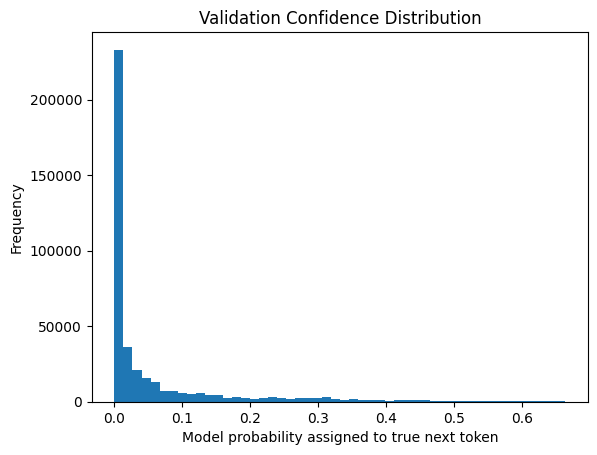

**Figure 1** shows the validation confidence distribution for the LSTM, the probability for true next token is near zero which means that the model is not confident in its choice for the next true token

## Quantitative Results (LSTM)

Validation loss/token: 5.6184

Validation perplexity: 275.44

Top-1 accuracy: 16.42%

Top-5 accuracy: 35.05%

The perplexity of 275 shows that the the model is on average choosing from about 275 different words that have equal probability of being the next token. For a word level model trained on a single story this is a lot of uncertainty which is expected.
The top-1 accuracy shows limited precision in next-token prediction but top-5 shows that the correct token is a lot of the times ranked among plausible tokens.

## Qualitative Comparison
### Gemini Output

The Gemini continuation demonstrates:
- Consistent characterisation of Poirot and Hastings
- Stylistic alignment with Agatha Christie's writing
- Coherent narrative progression
- Logical development of a clue (the misplaced teaspoon)

Sentences are grammatically correct and semantically consistent, they even maintain a narrative which preserves tone and has a structure.

LSTM Output

The LSTM continuation exhibits:
- Severe grammatical breakdown
- Loss of syntactic structure
- Repetition and malformed token spacing
- Inconsistent subject–verb agreement
- No stable narrative progression

The model is not consistent and fails to form any sort of coherence. The tokens are preserved but the structure is all over the place.

## Interpretation
| Aspect                | LSTM (Single Book)      | Gemini (Large LLM)        |
|----------------------|-------------------------|----------------------------|
| Training data scale  | Single novel            | Large-scale web corpus     |
| Model capacity       | Small recurrent network | Large transformer          |
| Long-range coherence | Very limited            | Strong                     |
| Grammatical control  | Weak                    | Strong                     |
| Narrative planning   | Absent                  | Structured                 |


Due to the large scale and extreme training Gemini has had it outperforms the LSTM by a huge margin. The LSTM would benefit by training on a larger dataset (a whole book or multiple books) to reduce perplexity and form more coherent sentences.

### Prompt given to Gemini

```
You are being asked to generate text in the style of a literary detective novel.

Continue the following prompt in approximately 200–300 words:

I was standing at the window of Poirot's rooms when he suddenly turned toward me and said,

Write the continuation in a style consistent with early 20th-century detective fiction by Agatha Christie. Maintain coherent narrative progression, consistent character behaviour, and logical development of events. Avoid meta commentary.
```

### Gemini's Response

```
I was standing at the window of Poirot's rooms when he suddenly turned toward me and said, 'Hastings, mon ami, have you ever considered the profound significance of the misplaced teaspoon?'

I blinked, momentarily distracted from the grey London drizzle. 'A teaspoon, Poirot? I can’t say I have. I was rather more concerned with the vanishing of the Marchester diamonds.'

'Precisely!' Poirot cried, waving his hands with a flourish that threatened the stability of his perfectly symmetrical moustache. 'The diamonds are the thunder, loud and distracting. But the teaspoon—ah, that is the quiet lightning! One does not simply find a silver Apostle spoon in the umbrella stand of a gentleman’s club unless the world has tilted on its axis.'

He paced the length of the hearthrug, his patent leather shoes clicking with rhythmic precision. He stopped to adjust a small porcelain figurine that had migrated a fraction of an inch to the left.

'You see, Hastings, the human mind is a creature of habit. When a habit is broken—even a small, culinary habit—it betrays a disturbance in the grey cells of the perpetrator. Someone was agitated. Someone was in a great hurry. And that someone, despite their haste, felt the need to conceal a piece of cutlery.'

'But surely it was just a prank,' I suggested, though I knew the futility of such a remark.

'A prank?' Poirot sighed, a look of profound disappointment clouding his face. 'You are an incurable romantic. No, it is a clue. A beautiful, shining clue that points directly to the heart of this little comedy. Fetch your hat, Hastings. We must visit the scene of this "prank" before the trail grows cold—or before someone decides to wash the dishes!

```


### Trained LSTM response

```
i was standing at the window of poirot' s rooms when he suddenly turned toward me and said." i cried, you, with my prime way in his time. i can know he have not all a little little."" oh, mr." you must think a two - -" there' t a face?"" yes' t so at a few." what is that?"" no, it' m one from my friend down for a moment? the doctor is been them before"" it are you, i was not at the same of the police that with poirot was so to her, but the other, of this own, who' m do of you? now as that we did in the case. we understand me that my eyes of the body and then he was going, the door seemed a police car of and his room will, we, it' s good man, or the young thing was - there is to been - i will so
```

In [ ]:
# ============================================================
# Imports and Drive Mounting
# ============================================================
from pathlib import Path
from google.colab import drive
drive.mount("/content/drive")

import os, re, math, json, random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [ ]:
# ============================================================
# Paths Configuration
# ============================================================
BASE = Path("/content/drive/My Drive/Deep Learning Assignment Final/Part 2")
DATA_DIR = BASE / "Data"

# New checkpoint folder for transformer
CKPT_DIR = BASE / "_checkpoints" / "gpt_wordlm_fixed"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

TEXT_PATH = DATA_DIR / "61262-0.txt"

def debug_list(p: Path, max_items=50):
    if not p.exists():
        print("Does not exist:", p)
        return
    print(f"Listing {p}:")
    items = sorted(list(p.iterdir()))
    for it in items[:max_items]:
        print(" -", it.name)
    if len(items) > max_items:
        print(" ... (more)")

assert BASE.exists(), f"Missing BASE: {BASE}"
assert DATA_DIR.exists(), f"Missing DATA_DIR: {DATA_DIR}\n" + "\n".join([str(x) for x in BASE.iterdir()])
if not TEXT_PATH.exists():
    debug_list(DATA_DIR)
    raise FileNotFoundError(f"Missing TEXT_PATH: {TEXT_PATH}")

print("BASE    :", BASE)
print("DATA_DIR:", DATA_DIR)
print("TEXT    :", TEXT_PATH)
print("CKPT    :", CKPT_DIR)

In [ ]:
# ============================================================
# Reproducibility and Device Setup
# ============================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

In [ ]:
# ============================================================
# Text Preprocessing Functions
# ============================================================
def strip_gutenberg_boilerplate(text: str) -> str:
    start_markers = [
        "*** START OF THIS PROJECT GUTENBERG EBOOK",
        "***START OF THIS PROJECT GUTENBERG EBOOK",
        "*** START OF THE PROJECT GUTENBERG EBOOK",
    ]
    end_markers = [
        "*** END OF THIS PROJECT GUTENBERG EBOOK",
        "***END OF THIS PROJECT GUTENBERG EBOOK",
        "*** END OF THE PROJECT GUTENBERG EBOOK",
    ]
    start_idx = 0
    for m in start_markers:
        i = text.find(m)
        if i != -1:
            start_idx = i
            break
    end_idx = len(text)
    for m in end_markers:
        i = text.find(m)
        if i != -1:
            end_idx = i
            break
    return text[start_idx:end_idx]

def normalize_text(s: str) -> str:
    s = s.replace("’", "'").replace("‘", "'")
    s = s.replace("“", '"').replace("”", '"')
    s = s.replace("—", "-").replace("–", "-")
    s = s.replace("\ufeff", "")
    s = re.sub(r"\s+", " ", s)
    return s.strip()

TOKEN_RE = re.compile(r"\w+|[^\w\s]", re.UNICODE)

def tokenize_words(s: str):
    return TOKEN_RE.findall(s)

In [ ]:
# ============================================================
# Load and Tokenize Text
# ============================================================
raw = TEXT_PATH.read_text(encoding="utf-8", errors="ignore")
text = normalize_text(strip_gutenberg_boilerplate(raw)).lower()
tokens = tokenize_words(text)

print("Total tokens:", len(tokens))
print("Preview:", " ".join(tokens[:60]))

In [ ]:
# ============================================================
# Train/Validation Split and Vocabulary Creation
# ============================================================
val_frac = 0.10
n_val = int(len(tokens) * val_frac)
train_tokens = tokens[:-n_val]
val_tokens   = tokens[-n_val:]

min_freq = 2  # if you overfit fast, try 3 or 5
specials = ["<PAD>", "<UNK>"]
counter = Counter(train_tokens)

itos = specials + [w for w, c in counter.items() if c >= min_freq]
stoi = {w:i for i,w in enumerate(itos)}

PAD_ID = stoi["<PAD>"]
UNK_ID = stoi["<UNK>"]
vocab_size = len(itos)

print("vocab_size:", vocab_size)

In [ ]:
# ============================================================
# Encode Tokens
# ============================================================
def encode(tok_list):
    return [stoi.get(t, UNK_ID) for t in tok_list]

train_ids = torch.tensor(encode(train_tokens), dtype=torch.long)
val_ids   = torch.tensor(encode(val_tokens), dtype=torch.long)

In [ ]:
# ============================================================
# ChunkDataset Class Definition
# ============================================================
class ChunkDataset(Dataset):
    def __init__(self, ids: torch.Tensor, seq_len: int, n_samples: int = 250_000):
        self.ids = ids
        self.seq_len = seq_len
        self.n_samples = n_samples

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        i = torch.randint(0, self.ids.size(0) - self.seq_len - 1, (1,)).item()
        x = self.ids[i:i+self.seq_len]
        y = self.ids[i+1:i+self.seq_len+1]
        return x, y

In [ ]:
# ============================================================
# CausalSelfAttention Class Definition
# ============================================================
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3*d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        att = att.masked_fill(mask, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.drop(att)
        y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.drop(self.proj(y))
        return y

In [ ]:
# ============================================================
# Block Class Definition
# ============================================================
class Block(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

In [ ]:
# ============================================================
# GPTWordLM Class Definition
# ============================================================
class GPTWordLM(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model=512, n_layers=6, n_heads=8, d_ff=2048, dropout=0.2):
        super().__init__()
        self.seq_len = seq_len
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight  # weight tying

    def forward(self, idx):
        B, T = idx.shape
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        return self.head(x)

In [ ]:
# ============================================================
# Save Helpers
# ============================================================
def save_bundle(out_dir: Path, model, meta, stoi, itos):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), out_dir / "model.pt")
    (out_dir / "meta.json").write_text(json.dumps(meta, indent=2))
    (out_dir / "stoi.json").write_text(json.dumps(stoi))
    (out_dir / "itos.json").write_text(json.dumps(itos))
    print("Saved:", out_dir)

In [ ]:
# ============================================================
# Proper Validation Perplexity Evaluation
# ============================================================
@torch.no_grad()
def eval_ppl_sequential(model, ids, seq_len, batch_size=16, max_tokens=200_000):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    N = ids.size(0) - 1
    N = min(N, max_tokens)

    max_start = N - seq_len - 1
    if max_start <= 0:
        raise ValueError("Validation set too small for chosen seq_len")

    starts = torch.arange(0, max_start, step=seq_len)

    for b in range(0, starts.numel(), batch_size):
        bs = starts[b:b+batch_size]
        if bs.numel() == 0:
            break

        x = torch.stack([ids[s:s+seq_len] for s in bs]).to(device)
        y = torch.stack([ids[s+1:s+seq_len+1] for s in bs]).to(device)

        logits = model(x)
        loss_sum = F.cross_entropy(
            logits.reshape(-1, vocab_size),
            y.reshape(-1),
            ignore_index=PAD_ID,
            reduction="sum"
        )
        total_loss += loss_sum.item()
        total_tokens += y.numel()

    mean_loss = total_loss / max(1, total_tokens)
    ppl = math.exp(mean_loss)
    return mean_loss, ppl

In [ ]:
# ============================================================
# Hyperparameters (fast + stable)
# ============================================================
seq_len = 128
d_model = 512
n_layers = 6
n_heads = 8
d_ff = 2048
dropout = 0.2

batch_size = 64
lr = 3e-4
weight_decay = 0.1
grad_clip = 1.0

eval_every = 400
max_steps = 2500
num_workers = 2

meta = dict(
    seq_len=seq_len,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    d_ff=d_ff,
    dropout=dropout,
    min_freq=min_freq,
    batch_size=batch_size,
    lr=lr,
    weight_decay=weight_decay
)

In [ ]:
# ============================================================
# Model Initialization and Optimizer Setup
# ============================================================
model = GPTWordLM(vocab_size, seq_len, d_model, n_layers, n_heads, d_ff, dropout).to(device)

train_ds = ChunkDataset(train_ids, seq_len, n_samples=250_000)
train_loader = DataLoader(train_ds, batch_size=batch_size, num_workers=num_workers, pin_memory=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=weight_decay)
scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)

best_val_ppl = float("inf")
patience = 2
bad_count = 0

print("Starting training...")
model.train()
step = 0

In [ ]:
# ============================================================
# Training Loop
# ============================================================
for x, y in train_loader:
    x = x.to(device, non_blocking=True)
    y = y.to(device, non_blocking=True)

    optimizer.zero_grad(set_to_none=True)

    with torch.cuda.amp.autocast(enabled=(device == "cuda")):
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1), ignore_index=PAD_ID)

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    scaler.step(optimizer)
    scaler.update()

    step += 1

    if step % 50 == 0:
        print(f"step {step:5d} | train loss {loss.item():.4f} | train ppl {math.exp(loss.item()):.1f}")

    if step % eval_every == 0:
        val_loss, val_ppl = eval_ppl_sequential(model, val_ids, seq_len, batch_size=16, max_tokens=200_000)
        print(f"==> VAL loss {val_loss:.4f} | VAL ppl {val_ppl:.1f}")

        save_bundle(CKPT_DIR / "latest", model, meta, stoi, itos)
        scheduler.step(val_loss)

        if val_ppl < best_val_ppl:
            best_val_ppl = val_ppl
            bad_count = 0
            save_bundle(CKPT_DIR / "best", model, meta, stoi, itos)
            print(f"*** NEW BEST saved | val ppl = {val_ppl:.2f} ***")
        else:
            bad_count += 1
            print(f"No improvement. bad_count={bad_count}/{patience}")
            if bad_count >= patience:
                print("Early stopping: validation not improving.")
                break

    if step >= max_steps:
        break

In [ ]:
# ============================================================
# Training Completion
# ============================================================
save_bundle(CKPT_DIR / "final", model, meta, stoi, itos)
print("Training done. Best val ppl:", best_val_ppl)

In [ ]:
# ============================================================
# Detokenization Function
# ============================================================
@torch.no_grad()
def detokenize(tok_list):
    s = ""
    for t in tok_list:
        if re.match(r"^\w+$", t):
            if s and not s.endswith(" "):
                s += " "
            s += t
        else:
            s += t
    return s

In [ ]:
# ============================================================
# Text Generation Function (Original)
# ============================================================
@torch.no_grad()
def generate(model, prompt, max_new_tokens=120, temperature=0.9, top_k=80):
    model.eval()
    toks = tokenize_words(prompt.lower())
    idx = [stoi.get(t, UNK_ID) for t in toks][-model.seq_len:]
    if len(idx) == 0:
        idx = [UNK_ID]
    idx = torch.tensor(idx, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.seq_len:]
        logits = model(idx_cond)[:, -1, :] / max(1e-6, temperature)

        if top_k is not None and top_k > 0:
            v, _ = torch.topk(logits, k=min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float("-inf")

        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)

    out_tokens = [itos[i] for i in idx[0].tolist()]
    return detokenize(out_tokens)

In [ ]:
# ============================================================
# Original Generation Examples
# ============================================================
print("\nGeneration examples:")
print(generate(model, "once upon a time"))
print("-"*80)
print(generate(model, "the queen said"))
print("-"*80)
print(generate(model, "in the middle of the night"))

In [10]:
@torch.no_grad()
def generate(
    model, prompt,
    max_new_tokens=120,
    temperature=0.9,
    top_k=80,
    repetition_penalty=1.08,
    no_repeat_ngram=3
):
    model.eval()
    toks = tokenize_words(prompt.lower())
    idx = [stoi.get(t, UNK_ID) for t in toks][-model.seq_len:]
    if len(idx) == 0:
        idx = [UNK_ID]
    idx = torch.tensor(idx, dtype=torch.long, device=device).unsqueeze(0)

    def ban_ngrams(prev_ids, logits, n):
        if prev_ids.numel() < n-1:
            return logits
        prev = prev_ids.tolist()
        ngrams = {}
        for i in range(len(prev) - n + 1):
            key = tuple(prev[i:i+n-1])
            nxt = prev[i+n-1]
            ngrams.setdefault(key, set()).add(nxt)
        key = tuple(prev[-(n-1):])
        banned = ngrams.get(key, set())
        if banned:
            logits[list(banned)] = -float("inf")
        return logits

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.seq_len:]
        logits = model(idx_cond)[:, -1, :].squeeze(0)

        if repetition_penalty and repetition_penalty != 1.0:
            seen = set(idx[0].tolist())
            for t in seen:
                if logits[t] > 0:
                    logits[t] /= repetition_penalty
                else:
                    logits[t] *= repetition_penalty

        logits = logits / max(1e-6, temperature)

        if no_repeat_ngram and no_repeat_ngram >= 2:
            logits = ban_ngrams(idx[0], logits, no_repeat_ngram)

        if top_k is not None and top_k > 0:
            v, _ = torch.topk(logits, k=min(top_k, logits.size(0)))
            logits[logits < v[-1]] = -float("inf")

        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).view(1, 1)
        idx = torch.cat([idx, next_id], dim=1)

    out_tokens = [itos[i] for i in idx[0].tolist()]
    return detokenize(out_tokens)

In [11]:
print(generate(model, "once upon a time", temperature=0.9, top_k=80, repetition_penalty=1.15, no_repeat_ngram=3))

once upon a time and<UNK> that he did not leave away in the bell. it has been found by his uncle' s story goes up to london about, _bien entendu_!"" mr. lowen( who fancied under great diamond of that every newspaper thousand pounds was just before we were sold in st?" i read between them on hand- makers use it from there. as good our female<UNK> into his own lips, placed three years ago my actions poirot arrived whilst general well somewhere. mrs. maltravers: miss blow on which those those those concealed there are unique towards him on sending the old ass, and rang again


In [5]:
@torch.no_grad()
def generate_top_p(
    model, prompt,
    max_new_tokens=150,
    temperature=0.85,
    top_p=0.92,
    repetition_penalty=1.12,
    no_repeat_ngram=3
):
    model.eval()
    toks = tokenize_words(prompt.lower())
    idx = [stoi.get(t, UNK_ID) for t in toks][-model.seq_len:]
    if len(idx) == 0:
        idx = [UNK_ID]
    idx = torch.tensor(idx, dtype=torch.long, device=device).unsqueeze(0)

    def apply_no_repeat_ngram(logits, prev_ids, n):
        if prev_ids.numel() < n - 1:
            return logits
        prev = prev_ids.tolist()
        ngrams = {}
        for i in range(len(prev) - n + 1):
            key = tuple(prev[i:i+n-1])
            nxt = prev[i+n-1]
            ngrams.setdefault(key, set()).add(nxt)
        key = tuple(prev[-(n-1):])
        banned = ngrams.get(key, set())
        if banned:
            logits[list(banned)] = -float("inf")
        return logits

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.seq_len:]
        logits = model(idx_cond)[:, -1, :].squeeze(0)

        # repetition penalty
        if repetition_penalty and repetition_penalty != 1.0:
            seen = set(idx[0].tolist())
            for t in seen:
                logits[t] = logits[t] / repetition_penalty if logits[t] > 0 else logits[t] * repetition_penalty

        logits = logits / max(1e-6, temperature)

        # no-repeat ngram
        if no_repeat_ngram and no_repeat_ngram >= 2:
            logits = apply_no_repeat_ngram(logits, idx[0], no_repeat_ngram)

        probs = torch.softmax(logits, dim=-1)

        # nucleus sampling
        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cum = torch.cumsum(sorted_probs, dim=0)
        cutoff = torch.searchsorted(cum, torch.tensor(top_p, device=cum.device))
        cutoff = int(cutoff.item())
        cutoff = max(1, cutoff)
        filt_idx = sorted_idx[:cutoff]
        filt_probs = sorted_probs[:cutoff]
        filt_probs = filt_probs / filt_probs.sum()

        next_id = filt_idx[torch.multinomial(filt_probs, 1)]
        idx = torch.cat([idx, next_id.view(1, 1)], dim=1)

    out_tokens = [itos[i] for i in idx[0].tolist()]
    return detokenize(out_tokens)

In [6]:
print(generate_top_p(model, "once upon a time", temperature=0.8, top_p=0.9, repetition_penalty=1.15, no_repeat_ngram=3))
print(generate_top_p(model, "the queen said", temperature=0.8, top_p=0.9, repetition_penalty=1.15, no_repeat_ngram=3))

once upon a time and<UNK>" was about twenty- night' s voice to that department, but monsieur poirot?" i cried with an audience." she caught in vain we descended slowly there before unfortunately taken part of it seemed to this events almost unbelievable romanticism the premiums on towards me hastily as usual politeness politeness politeness. i found far they were excitement in mrs. maltravers unduly by terrified to see how much agitated:" then perhaps your son, you never do not believe he pulled back for some tools on the way out from new york?"" madame day, if _i_ recognize her mouse in buenos ayres last three o' clock when every one higher than mr. bleibner unlocked a quarter past five or twice got no details as soon enough now, i understand at all their
the<UNK> said to be there. no one:' s a man," he cried lord estair still observe us and turned to him that poirot thoughtfully. his ear towards stretched out of my friend returned in front i heard me from hubbs- amusing him gingerly 

In [7]:
@torch.no_grad()
def generate_topk_clean(
    model, prompt,
    max_new_tokens=140,
    temperature=0.9,
    top_k=80,
    repetition_penalty=1.08,   # keep mild; too high hurts fluency
    no_repeat_ngram=0          # OFF by default; can turn to 3 if looping
):
    model.eval()
    toks = tokenize_words(prompt.lower())
    idx = [stoi.get(t, UNK_ID) for t in toks][-model.seq_len:]
    if len(idx) == 0:
        idx = [UNK_ID]
    idx = torch.tensor(idx, dtype=torch.long, device=device).unsqueeze(0)

    def ban_ngrams(prev_ids, logits, n):
        if prev_ids.numel() < n-1:
            return logits
        prev = prev_ids.tolist()
        ngrams = {}
        for i in range(len(prev) - n + 1):
            key = tuple(prev[i:i+n-1])
            nxt = prev[i+n-1]
            ngrams.setdefault(key, set()).add(nxt)
        key = tuple(prev[-(n-1):])
        banned = ngrams.get(key, set())
        if banned:
            logits[list(banned)] = -float("inf")
        return logits

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.seq_len:]
        logits = model(idx_cond)[:, -1, :].squeeze(0)

        # mild repetition penalty
        if repetition_penalty and repetition_penalty != 1.0:
            seen = set(idx[0].tolist())
            for t in seen:
                logits[t] = logits[t] / repetition_penalty if logits[t] > 0 else logits[t] * repetition_penalty

        logits = logits / max(1e-6, temperature)

        # optional no-repeat ngram
        if no_repeat_ngram and no_repeat_ngram >= 2:
            logits = ban_ngrams(idx[0], logits, no_repeat_ngram)

        # top-k
        if top_k is not None and top_k > 0:
            v, _ = torch.topk(logits, k=min(top_k, logits.size(0)))
            logits[logits < v[-1]] = -float("inf")

        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, 1)
        idx = torch.cat([idx, next_id.view(1, 1)], dim=1)

    out_tokens = [itos[i] for i in idx[0].tolist()]
    return detokenize(out_tokens)

In [9]:
print(generate_topk_clean(model, "once upon a time", temperature=0.9, top_k=80, repetition_penalty=1.0))

once upon a time and<UNK> in<UNK> in his place. no end of<UNK> in<UNK> which was two<UNK>. he alone can be again how<UNK> england in egypt if they can be hoped<UNK> to paris." forty forty, and a marvel, without the whole affair does that' s foreign government poirot. on the drawer of them. serve his right and bolted. he' s dread news in the way into that!" we descended to the man with a grudge against the post office; that he was<UNK> with a accorded accorded a lean, if you not catch somewhere?" poirot' s partner, i should hope."" i' ve not thinking of<UNK>- i guess she' s not good deal


In [ ]:
# -------------------------
# 2) Text preprocessing
# -------------------------
def strip_gutenberg_boilerplate(text: str) -> str:
    start_markers = [
        "*** START OF THIS PROJECT GUTENBERG EBOOK",
        "***START OF THIS PROJECT GUTENBERG EBOOK",
        "*** START OF THE PROJECT GUTENBERG EBOOK",
    ]
    end_markers = [
        "*** END OF THIS PROJECT GUTENBERG EBOOK",
        "***END OF THIS PROJECT GUTENBERG EBOOK",
        "*** END OF THE PROJECT GUTENBERG EBOOK",
    ]
    start_idx = 0
    for m in start_markers:
        i = text.find(m)
        if i != -1:
            start_idx = i
            break
    end_idx = len(text)
    for m in end_markers:
        i = text.find(m)
        if i != -1:
            end_idx = i
            break
    return text[start_idx:end_idx]

def normalize_text(s: str) -> str:
    s = s.replace("’", "'").replace("‘", "'")
    s = s.replace("“", '"').replace("”", '"')
    s = s.replace("—", "-").replace("–", "-")
    s = s.replace("\ufeff", "")
    s = re.sub(r"\s+", " ", s)
    return s.strip()

TOKEN_RE = re.compile(r"\w+|[^\w\s]", re.UNICODE)

def tokenize_words(s: str):
    return TOKEN_RE.findall(s)

raw = TEXT_PATH.read_text(encoding="utf-8", errors="ignore")
text = normalize_text(strip_gutenberg_boilerplate(raw)).lower()
tokens = tokenize_words(text)

print("Total tokens:", len(tokens))
print("Preview:", " ".join(tokens[:60]))

# -------------------------
# 3) Split + Vocab (KEY: min_freq=1)
# -------------------------
val_frac = 0.10
n_val = int(len(tokens) * val_frac)
train_tokens = tokens[:-n_val]
val_tokens   = tokens[-n_val:]

min_freq = 1  # <<<<<<<<<<<<<<<<<<<<<<<<<<<
specials = ["<PAD>", "<UNK>"]

counter = Counter(train_tokens)
itos = specials + [w for w, c in counter.items() if c >= min_freq]
stoi = {w:i for i,w in enumerate(itos)}

PAD_ID = stoi["<PAD>"]
UNK_ID = stoi["<UNK>"]
vocab_size = len(itos)

print("vocab_size:", vocab_size)

def encode(tok_list):
    return [stoi.get(t, UNK_ID) for t in tok_list]

train_ids = torch.tensor(encode(train_tokens), dtype=torch.long)
val_ids   = torch.tensor(encode(val_tokens), dtype=torch.long)

# -------------------------
# 4) Dataset
# -------------------------
class ChunkDataset(Dataset):
    def __init__(self, ids: torch.Tensor, seq_len: int, n_samples: int = 250_000):
        self.ids = ids
        self.seq_len = seq_len
        self.n_samples = n_samples

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        i = torch.randint(0, self.ids.size(0) - self.seq_len - 1, (1,)).item()
        x = self.ids[i:i+self.seq_len]
        y = self.ids[i+1:i+self.seq_len+1]
        return x, y

# -------------------------
# 5) Model
# -------------------------
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3*d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        att = att.masked_fill(mask, float("-inf"))
        att = torch.softmax(att, dim=-1)
        att = self.drop(att)
        y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.drop(self.proj(y))
        return y

class Block(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class GPTWordLM(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model=512, n_layers=6, n_heads=8, d_ff=2048, dropout=0.25):
        super().__init__()
        self.seq_len = seq_len
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight  # weight tying

    def forward(self, idx):
        B, T = idx.shape
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        return self.head(x)

# -------------------------
# 6) Save + Validation
# -------------------------
def save_bundle(out_dir: Path, model, meta, stoi, itos):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), out_dir / "model.pt")
    (out_dir / "meta.json").write_text(json.dumps(meta, indent=2))
    (out_dir / "stoi.json").write_text(json.dumps(stoi))
    (out_dir / "itos.json").write_text(json.dumps(itos))
    print("Saved:", out_dir)

@torch.no_grad()
def eval_ppl_sequential(model, ids, seq_len, batch_size=16, max_tokens=250_000):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    N = ids.size(0) - 1
    N = min(N, max_tokens)

    max_start = N - seq_len - 1
    if max_start <= 0:
        raise ValueError("Validation set too small for chosen seq_len")

    starts = torch.arange(0, max_start, step=seq_len)

    for b in range(0, starts.numel(), batch_size):
        bs = starts[b:b+batch_size]
        if bs.numel() == 0:
            break

        x = torch.stack([ids[s:s+seq_len] for s in bs]).to(device)
        y = torch.stack([ids[s+1:s+seq_len+1] for s in bs]).to(device)

        logits = model(x)
        loss_sum = F.cross_entropy(
            logits.reshape(-1, vocab_size),
            y.reshape(-1),
            ignore_index=PAD_ID,
            reduction="sum"
        )
        total_loss += loss_sum.item()
        total_tokens += y.numel()

    mean_loss = total_loss / max(1, total_tokens)
    ppl = math.exp(mean_loss)
    return mean_loss, ppl

# -------------------------
# 7) Hyperparams
# -------------------------
seq_len = 128
d_model = 512
n_layers = 6
n_heads = 8
d_ff = 2048
dropout = 0.25

batch_size = 64
lr = 3e-4
weight_decay = 0.1
grad_clip = 1.0

eval_every = 400
max_steps = 3200   # early stopping should stop earlier
num_workers = 2

meta = dict(
    seq_len=seq_len,
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    d_ff=d_ff,
    dropout=dropout,
    min_freq=min_freq,
    batch_size=batch_size,
    lr=lr,
    weight_decay=weight_decay
)

# -------------------------
# 8) Train (best + early stop)
# -------------------------
model = GPTWordLM(vocab_size, seq_len, d_model, n_layers, n_heads, d_ff, dropout).to(device)

train_ds = ChunkDataset(train_ids, seq_len, n_samples=250_000)
train_loader = DataLoader(train_ds, batch_size=batch_size, num_workers=num_workers, pin_memory=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=weight_decay)
scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

best_val_ppl = float("inf")
patience = 2
bad_count = 0

print("Starting training...")
model.train()
step = 0

for x, y in train_loader:
    x = x.to(device, non_blocking=True)
    y = y.to(device, non_blocking=True)

    optimizer.zero_grad(set_to_none=True)

    with torch.cuda.amp.autocast(enabled=(device == "cuda")):
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1), ignore_index=PAD_ID)

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    scaler.step(optimizer)
    scaler.update()

    step += 1
    if step % 50 == 0:
        print(f"step {step:5d} | train loss {loss.item():.4f} | train ppl {math.exp(loss.item()):.1f}")

    if step % eval_every == 0:
        val_loss, val_ppl = eval_ppl_sequential(model, val_ids, seq_len, batch_size=16, max_tokens=250_000)
        print(f"==> VAL loss {val_loss:.4f} | VAL ppl {val_ppl:.1f}")

        save_bundle(CKPT_DIR / "latest", model, meta, stoi, itos)

        if val_ppl < best_val_ppl:
            best_val_ppl = val_ppl
            bad_count = 0
            save_bundle(CKPT_DIR / "best", model, meta, stoi, itos)
            print(f"*** NEW BEST saved | val ppl = {val_ppl:.2f} ***")
        else:
            bad_count += 1
            print(f"No improvement. bad_count={bad_count}/{patience}")
            if bad_count >= patience:
                print("Early stopping.")
                break

    if step >= max_steps:
        break

save_bundle(CKPT_DIR / "final", model, meta, stoi, itos)
print("Training done. Best val ppl:", best_val_ppl)

# -------------------------
# 9) Generation (your chosen method, shape-fixed)
# -------------------------
@torch.no_grad()
def detokenize(tok_list):
    s = ""
    for t in tok_list:
        if re.match(r"^\w+$", t):
            if s and not s.endswith(" "):
                s += " "
            s += t
        else:
            s += t
    return s

@torch.no_grad()
def generate(
    model, prompt,
    max_new_tokens=140,
    temperature=0.85,
    top_k=80,
    repetition_penalty=1.08,
    no_repeat_ngram=3
):
    model.eval()
    toks = tokenize_words(prompt.lower())
    idx = [stoi.get(t, UNK_ID) for t in toks][-model.seq_len:]
    if len(idx) == 0:
        idx = [UNK_ID]
    idx = torch.tensor(idx, dtype=torch.long, device=device).unsqueeze(0)

    def ban_ngrams(prev_ids, logits, n):
        if prev_ids.numel() < n-1:
            return logits
        prev = prev_ids.tolist()
        ngrams = {}
        for i in range(len(prev) - n + 1):
            key = tuple(prev[i:i+n-1])
            nxt = prev[i+n-1]
            ngrams.setdefault(key, set()).add(nxt)
        key = tuple(prev[-(n-1):])
        banned = ngrams.get(key, set())
        if banned:
            logits[list(banned)] = -float("inf")
        return logits

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.seq_len:]
        logits = model(idx_cond)[:, -1, :].squeeze(0)

        if repetition_penalty and repetition_penalty != 1.0:
            seen = set(idx[0].tolist())
            for t in seen:
                logits[t] = logits[t] / repetition_penalty if logits[t] > 0 else logits[t] * repetition_penalty

        logits = logits / max(1e-6, temperature)

        if no_repeat_ngram and no_repeat_ngram >= 2:
            logits = ban_ngrams(idx[0], logits, no_repeat_ngram)

        if top_k is not None and top_k > 0:
            v, _ = torch.topk(logits, k=min(top_k, logits.size(0)))
            logits[logits < v[-1]] = -float("inf")

        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).view(1, 1)
        idx = torch.cat([idx, next_id], dim=1)

    out_tokens = [itos[i] for i in idx[0].tolist()]
    return detokenize(out_tokens)

print("\nTry generation:")
print(generate(model, "poirot said"))
print("-"*80)
print(generate(model, "captain hastings"))
print("-"*80)
print(generate(model, "the room was"))

Total tokens: 68386
Preview: * * * start of the project gutenberg ebook 61262 * * * poirot investigates by the same author the mysterious affair at styles the secret adversary the murder on the links the bodley head poirot investigates by agatha christie london john lane the bodley head limited first published in great britain by john lane company , the bodley head
vocab_size: 5628
Starting training...


/tmp/ipython-input-4031606642.py:258: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))
/tmp/ipython-input-4031606642.py:274: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


step    50 | train loss 21.7391 | train ppl 2761754291.1
step   100 | train loss 16.8766 | train ppl 21350036.9
step   150 | train loss 14.3527 | train ppl 1711138.9
step   200 | train loss 12.5959 | train ppl 295337.7
step   250 | train loss 11.5413 | train ppl 102881.0
step   300 | train loss 10.5883 | train ppl 39668.9
step   350 | train loss 9.8771 | train ppl 19479.9
step   400 | train loss 9.6518 | train ppl 15549.8
==> VAL loss 10.4765 | VAL ppl 35471.6
Saved: /content/drive/My Drive/Deep Learning Assignment Final/Part 2/_checkpoints/gpt_wordlm_fixed/latest
Saved: /content/drive/My Drive/Deep Learning Assignment Final/Part 2/_checkpoints/gpt_wordlm_fixed/best
*** NEW BEST saved | val ppl = 35471.58 ***
step   450 | train loss 5.6181 | train ppl 275.4
step   500 | train loss 5.7125 | train ppl 302.6
step   550 | train loss 5.5203 | train ppl 249.7
step   600 | train loss 5.3083 | train ppl 202.0
step   650 | train loss 5.1222 | train ppl 167.7
step   700 | train loss 5.0544 | tra